In [1]:
import yfinance as yf

In [2]:
from datetime import datetime
end = datetime.now()
start = datetime(end.year-20, end.month, end.day)

In [3]:
stock = "HDB"
HDFC_data = yf.download(stock, start, end)

[*********************100%***********************]  1 of 1 completed


In [4]:
HDFC_data.tail()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2024-10-21,62.500000,64.180000,62.500000,63.500000,63.500000,4999200
2024-10-22,63.099998,63.259998,62.880001,63.139999,63.139999,1467600
2024-10-23,63.250000,64.199997,63.130001,64.169998,64.169998,2567800
2024-10-24,64.300003,64.440002,64.169998,64.239998,64.239998,1290000
2024-10-25,64.000000,64.300003,63.560001,63.779999,63.779999,251952


In [5]:
HDFC_data.shape


(5036, 6)

In [6]:
HDFC_data.describe()

,Open,High,Low,Close,Adj Close,Volume
count,5036.000000,5036.000000,5036.000000,5036.000000,5036.000000,5.036000e+03
mean,32.012105,32.309507,31.694498,32.005850,30.891024,2.346216e+06
std,22.712671,22.877048,22.531189,22.702492,22.606614,2.003275e+06
min,3.170000,3.199000,3.134000,3.160000,2.792591,1.970000e+05
25%,12.568250,12.781000,12.312750,12.574750,11.395714,1.189950e+06
50%,25.139999,25.275001,24.875000,25.049999,23.679253,1.719950e+06
75%,53.365001,53.865000,52.885001,53.359999,52.239693,2.713200e+06
max,84.699997,84.699997,83.029999,83.750000,81.654846,2.214700e+07


In [7]:
import matplotlib.pyplot as plt
%matplotlib inline

Text(0.5, 1.0, 'Closing price of HDFC data')

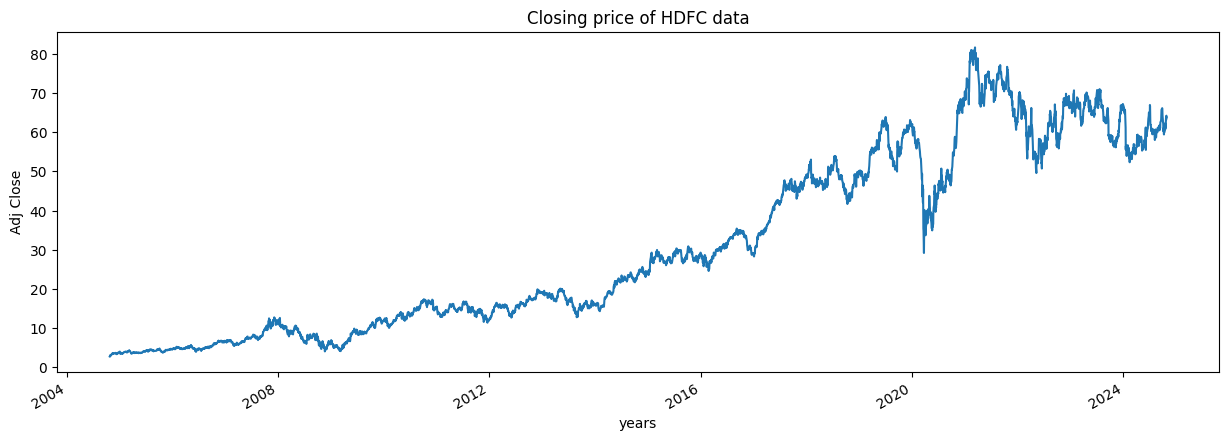

In [8]:
plt.figure(figsize = (15,5))
HDFC_data['Adj Close'].plot()
plt.xlabel("years")
plt.ylabel("Adj Close")
plt.title("Closing price of HDFC data")

In [9]:
HDFC_data.columns

Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [10]:
def plot_graph(figsize, values, column_name):
    plt.figure()
    values.plot(figsize = figsize)
    plt.xlabel("years")
    plt.ylabel(column_name)
    plt.title(f"{column_name} of HDFC data")

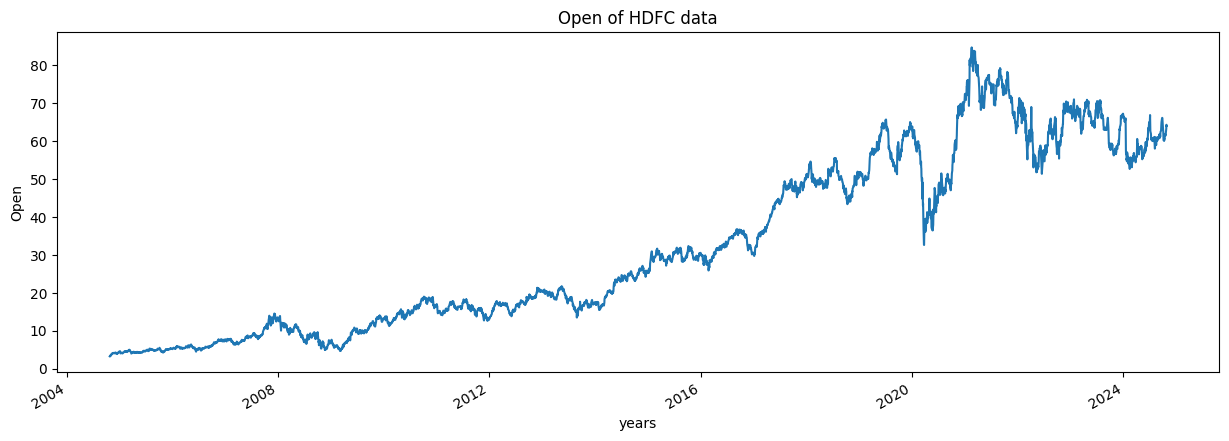

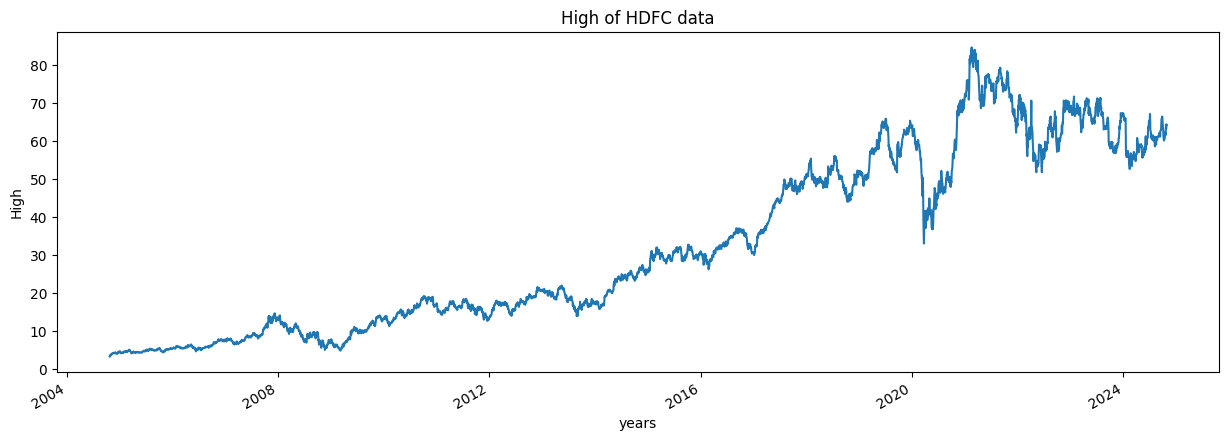

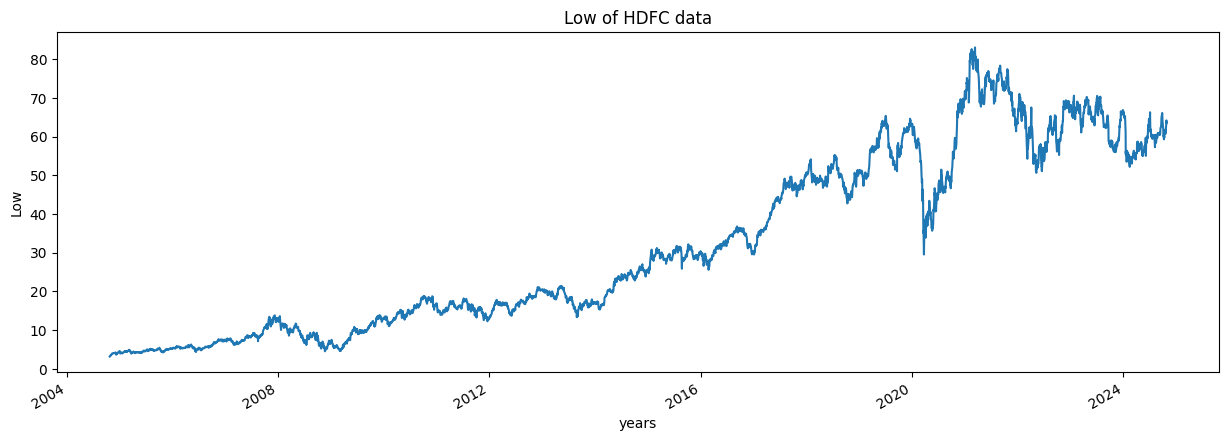

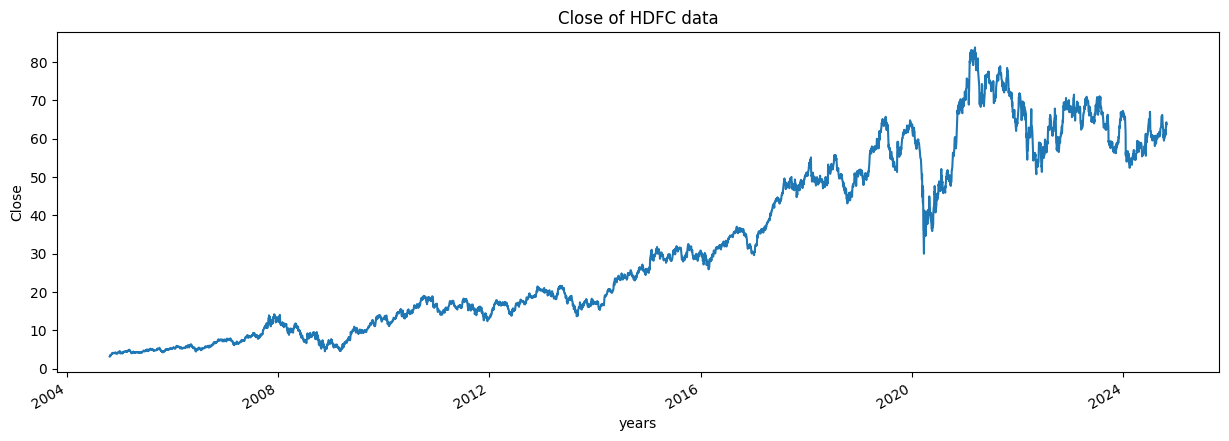

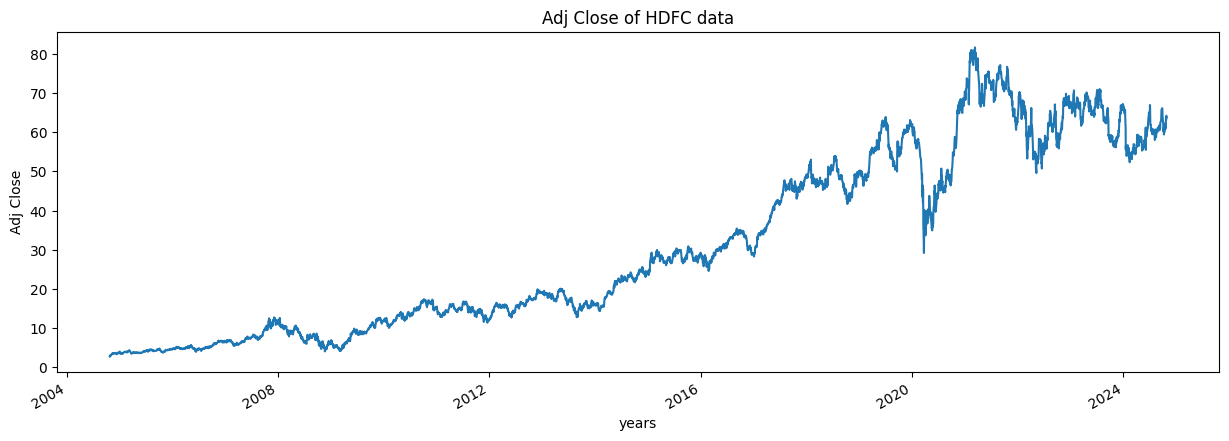

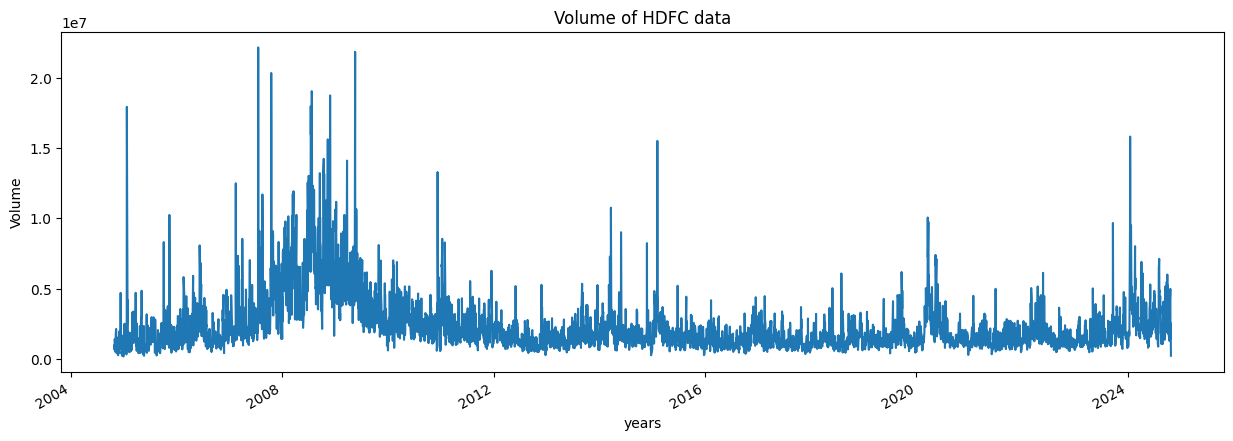

In [11]:
for column in HDFC_data.columns:
    plot_graph((15,5),HDFC_data[column], column)

In [12]:
# 10, 20, 30, 40, 50, 60, 70, 80, 90, 100

# MA for 5 days ==> null null null null 30 40 50 60 70 80

In [13]:
temp_data = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
print(sum(temp_data[1:6])/5)

40.0


In [14]:
import pandas as pd
data = pd.DataFrame([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
data.head()

,0
0,10
1,20
2,30
3,40
4,50


In [15]:
data['MA'] = data.rolling(5).mean()
data

,0,MA
0,10,NaN
1,20,NaN
2,30,NaN
3,40,NaN
4,50,30.0
5,60,40.0
6,70,50.0
7,80,60.0
8,90,70.0
9,100,80.0


In [16]:
for i in range(2004,2025):
    print(i,list(HDFC_data.index.year).count(i))

2004 48
2005 252
2006 251
2007 251
2008 253
2009 252
2010 252
2011 252
2012 250
2013 252
2014 252
2015 252
2016 252
2017 251
2018 251
2019 252
2020 253
2021 252
2022 251
2023 250
2024 207


In [17]:
HDFC_data['MA_for_250_days'] = HDFC_data['Adj Close'].rolling(250).mean()

In [18]:
HDFC_data['MA_for_250_days']

Date
2004-10-25         NaN
2004-10-26         NaN
2004-10-27         NaN
2004-10-28         NaN
2004-10-29         NaN
                ...   
2024-10-21    59.47168
2024-10-22    59.49600
2024-10-23    59.52348
2024-10-24    59.55316
2024-10-25    59.58296
Name: MA_for_250_days, Length: 5036, dtype: float64

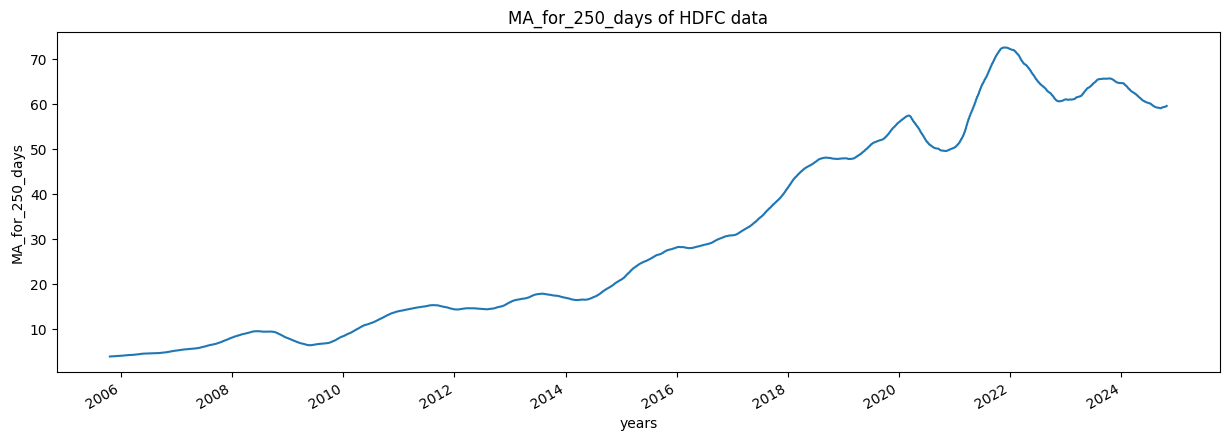

In [19]:
plot_graph((15,5), HDFC_data['MA_for_250_days'], 'MA_for_250_days')

<Figure size 640x480 with 0 Axes>

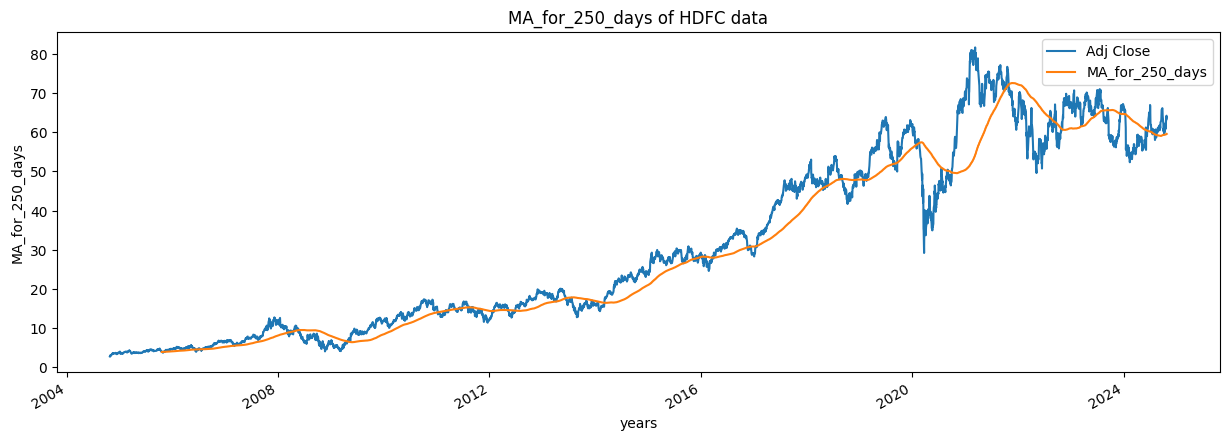

In [20]:
plot_graph((15,5), HDFC_data[['Adj Close','MA_for_250_days']], 'MA_for_250_days')

<Figure size 640x480 with 0 Axes>

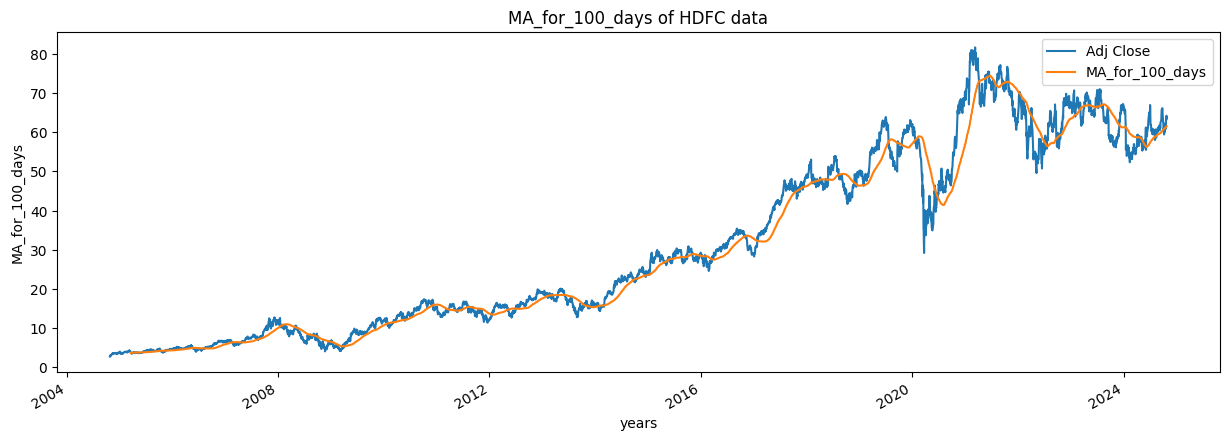

In [21]:
HDFC_data['MA_for_100_days'] = HDFC_data['Adj Close'].rolling(100).mean()
plot_graph((15,5), HDFC_data[['Adj Close','MA_for_100_days']], 'MA_for_100_days')

In [22]:
HDFC_data['percentage_change_cp'] = HDFC_data['Adj Close'].pct_change()
HDFC_data[['Adj Close','percentage_change_cp']].tail()

,Adj Close,percentage_change_cp
Date,,
2024-10-21,63.500000,0.043207
2024-10-22,63.139999,-0.005669
2024-10-23,64.169998,0.016313
2024-10-24,64.239998,0.001091
2024-10-25,63.779999,-0.007161


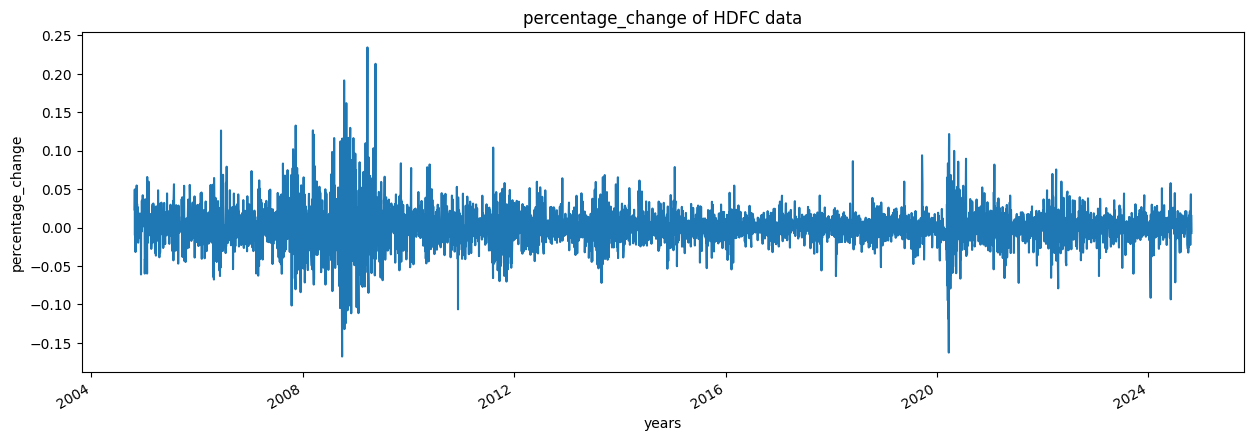

In [23]:
plot_graph((15,5), HDFC_data['percentage_change_cp'], 'percentage_change')

In [24]:
Adj_close_price = HDFC_data[['Adj Close']]

In [25]:
max(Adj_close_price.values),min(Adj_close_price.values) 

(array([81.65484619]), array([2.79259133]))

In [26]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(Adj_close_price)
scaled_data

array([[0.        ],
       [0.00082926],
       [0.00262221],
       ...,
       [0.77828623],
       [0.77917385],
       [0.7733409 ]])

In [27]:
len(scaled_data)

5036

In [28]:
x_data = []
y_data = []

for i in range(100, len(scaled_data)):
    x_data.append(scaled_data[i-100:i])
    y_data.append(scaled_data[i])
    
import numpy as np
x_data, y_data = np.array(x_data), np.array(y_data)

In [29]:
x_data[0],y_data[0]

(array([[0.        ],
        [0.00082926],
        [0.00262221],
        [0.00223001],
        [0.00400055],
        [0.00274548],
        [0.0035299 ],
        [0.00425829],
        [0.00459447],
        [0.00617452],
        [0.00661156],
        [0.00890878],
        [0.00852778],
        [0.0081804 ],
        [0.00952513],
        [0.00915533],
        [0.01017506],
        [0.00991733],
        [0.01110517],
        [0.01018627],
        [0.0098389 ],
        [0.00940186],
        [0.00941306],
        [0.0098613 ],
        [0.01007421],
        [0.01053366],
        [0.01137412],
        [0.01199044],
        [0.0113629 ],
        [0.01137412],
        [0.01131808],
        [0.01065692],
        [0.00784422],
        [0.00778818],
        [0.00812437],
        [0.00790025],
        [0.00941306],
        [0.00942426],
        [0.00969322],
        [0.00997336],
        [0.01187838],
        [0.01194563],
        [0.01285331],
        [0.01367135],
        [0.01411959],
        [0

In [30]:
int(len(x_data)*0.7)

3455

In [31]:
5036-100-int(len(x_data)*0.7)

1481

In [32]:
splitting_len = int(len(x_data)*0.7)
x_train = x_data[:splitting_len]
y_train = y_data[:splitting_len]

x_test = x_data[splitting_len:]
y_test = y_data[splitting_len:]

In [33]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(3455, 100, 1)
(3455, 1)
(1481, 100, 1)
(1481, 1)


In [34]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense

In [35]:
from keras.layers import LSTM

In [36]:
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape=(x_train.shape[1],1)))
model.add(LSTM(64,return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

C:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [37]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [38]:
model.fit(x_train, y_train, batch_size=1, epochs = 2)

Epoch 1/2
3455/3455 ━━━━━━━━━━━━━━━━━━━━ 184s 51ms/step - loss: 0.0013
Epoch 2/2
3455/3455 ━━━━━━━━━━━━━━━━━━━━ 164s 48ms/step - loss: 1.7750e-04


In [39]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 128)            │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 25)                  │           1,625 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

In [40]:
predictions = model.predict(x_test)

47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step


In [41]:
predictions

array([[0.574795  ],
       [0.5748663 ],
       [0.5588224 ],
       ...,
       [0.75144964],
       [0.7616918 ],
       [0.7670255 ]], dtype=float32)

In [42]:
inv_predictions = scaler.inverse_transform(predictions)
inv_predictions

array([[48.122223],
       [48.127842],
       [46.862587],
       ...,
       [62.053604],
       [62.861324],
       [63.281948]], dtype=float32)

In [43]:
inv_y_test = scaler.inverse_transform(y_test)
inv_y_test

array([[48.63066864],
       [46.12313843],
       [46.25867844],
       ...,
       [64.16999817],
       [64.23999786],
       [63.77999878]])

In [44]:
rmse = np.sqrt(np.mean( (inv_predictions - inv_y_test)**2))
rmse

1.547463833249449

In [62]:
import numpy as np

inv_predictions = np.array([inv_predictions])
inv_y_test = np.array([inv_y_test])

# Calculate MAPE
mape = np.mean(np.abs((inv_y_test - inv_predictions) / inv_y_test)) * 100

# Calculate accuracy based on MAPE
accuracy = 100 - mape

print(f"MAPE: {mape}%")
print(f"Accuracy: {accuracy}%")


MAPE: 2.03668513364862%
Accuracy: 97.96331486635138%


In [46]:
ploting_data = pd.DataFrame(
 {
  'original_test_data': inv_y_test.reshape(-1),
    'predictions': inv_predictions.reshape(-1)
 } ,
    index = HDFC_data.index[splitting_len+100:]
)
ploting_data

,original_test_data,predictions
Date,,
2018-12-07,48.630669,48.122223
2018-12-10,46.123138,48.127842
2018-12-11,46.258678,46.862587
2018-12-12,47.764164,45.987423
2018-12-13,48.775894,46.391010
...,...,...
2024-10-21,63.500000,60.264286
2024-10-22,63.139999,61.334229
2024-10-23,64.169998,62.053604


<Figure size 640x480 with 0 Axes>

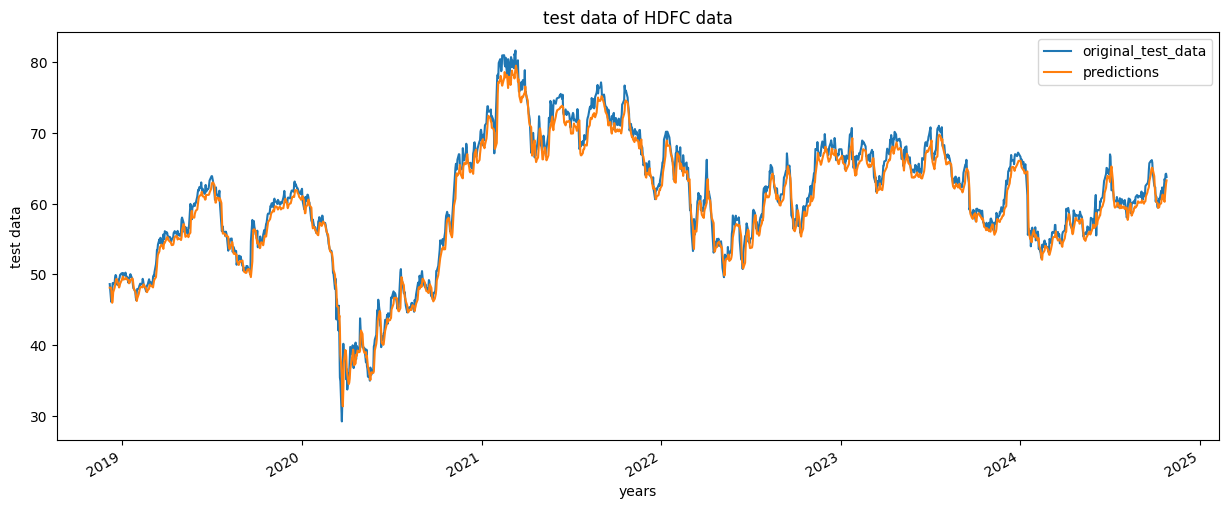

In [47]:
plot_graph((15,6), ploting_data, 'test data')

<Figure size 640x480 with 0 Axes>

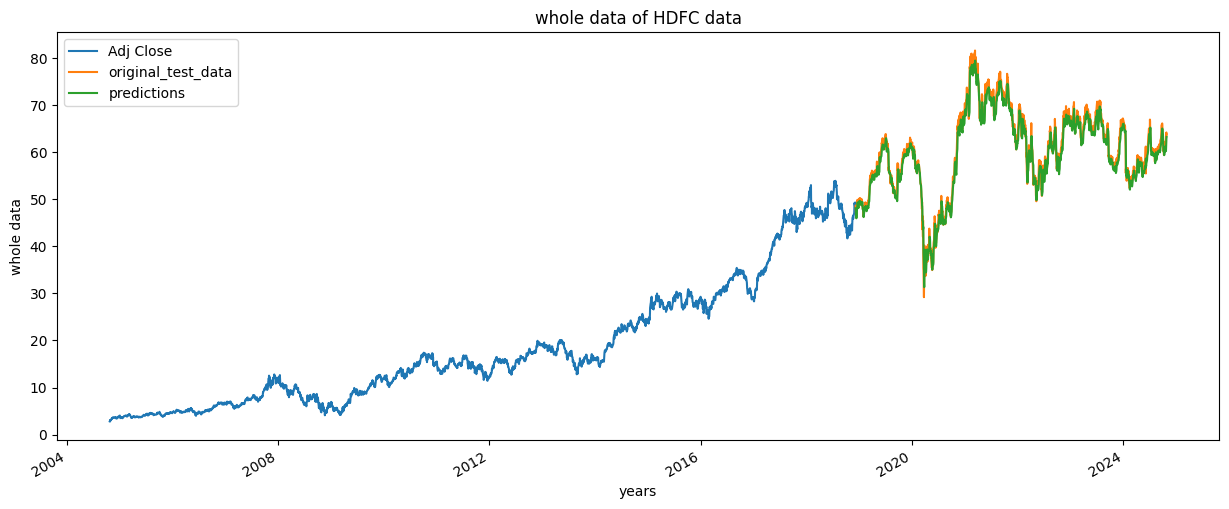

In [48]:
plot_graph((15,6), pd.concat([Adj_close_price[:splitting_len+100],ploting_data], axis=0), 'whole data')

In [49]:
pip install pandas_datareader

Note: you may need to restart the kernel to use updated packages.


In [50]:
import pandas_datareader as pdr
from datetime import datetime



# Fetch the stock data for HDFC from Yahoo Finance
stock = "HDB"
HDFC_data = yf.download(stock, start='2017-1-10', end='2024-10-16')

new_df=HDFC_data.filter(['Close'])
last_60_days=new_df[-60:].values
last_60_days_scaled=scaler.transform(last_60_days)
x_test=[]
x_test.append(last_60_days_scaled)
x_test=np.array(x_test)
x_test=np.reshape(x_test, (x_test.shape[0],x_test.shape[1],1))
pred_price=model.predict(x_test)
pred_price=scaler.inverse_transform(pred_price)
print(pred_price)

[*********************100%***********************]  1 of 1 completed
C:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step
[[60.878036]]


In [57]:
model.save("Latest_sp_model.keras")